# Major Project

**Domain:** Semiconductor Manufacturing Process  
**Objective:** Predict Pass/Fail yield and identify whether all sensor signals are required.

The dataset contains 1,567 production entities, 590 sensor variables, a timestamp, and the `Pass/Fail` target.

**Note**
Before running the notebook, please manually upload the signal-data.csv file when prompted. The dataset is not stored permanently in Google Colab, so I had to write code so you have to manually upload the file.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from google.colab import files

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("File loaded:", file_name)
print("Shape:", df.shape)
display(df.head())
print("\nDataset Information:")
df.info()


Saving signal-data.csv to signal-data (1).csv
File loaded: signal-data (1).csv
Shape: (1567, 592)


,Time,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,...,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,...,11.5074,0.1096,0.0078,0.0026,7.116,1.0616,395.570,75.752,0.4234,12.93,0.78,0.1827,5.7349,0.3363,39.8842,3.2687,1.0297,1.0344,0.4385,0.1039,42.3877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,10.1548,414.7347,9.2599,0.9701,191.2872,12.4608,1.3825,-5441.50,2604.25,-3498.75,-1640.25,1.2973,2.0143,7.3900,68.4222,2.2667,0.2102,3.4171,84.9052,9.7997,50.6596,64.2828,49.3404,64.9193,87.5241,118.1188,78.25,2.773,70.0,352.2445,10.0373,133.1727,724.8264,1.2887,145.8445,...,9.5796,0.1096,0.0078,0.0026,7.116,1.3526,408.798,74.640,0.7193,16.00,1.33,0.2829,7.1196,0.4989,53.1836,3.9139,1.7819,0.9634,0.1745,0.0375,18.1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,9.5157,416.7075,9.3144,0.9674,192.7035,12.5404,1.4123,-5447.75,2701.75,-4047.00,-1916.50,1.3122,2.0295,7.5788,67.1333,2.3333,0.1734,3.5986,84.7569,8.6590,50.1530,64.1114,49.8470,65.8389,84.7327,118.6128,14.37,5.434,70.0,364.3782,9.8783,131.8027,734.7924,1.2992,141.0845,...,9.3046,0.1096,0.0078,0.0026,7.116,0.7942,411.136,74.654,0.1832,16.16,0.85,0.0857,7.1619,0.3752,23.0713,3.9306,1.1386,1.5021,0.3718,0.1233,24.7524,267.064,0.9032,1.10,0.6219,0.4122,0.2562,0.4119,68.8489,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,9.6052,422.2894,9.6924,0.9687,192.1557,12.4782,1.4011,-5468.25,2648.25,-4515.00,-1657.25,1.3137,2.0038,7.3145,62.9333,2.6444,0.2071,3.3813,84.9105,8.6789,50.5100,64.1125,49.4900,65.1951,86.6867,117.0442,76.90,1.279,70.0,363.0273,9.9305,131.8027,733.8778,1.3027,142.5427,...,7.7754,0.1096,0.0078,0.0026,7.116,1.1650,372.822,72.442,1.8804,131.68,39.33,0.6812,56.9303,17.4781,161.4081,35.3198,54.2917,1.1613,0.7288,0.2710,62.7572,268.228,0.6511,7.32,0.1630,3.5611,0.0670,2.7290,25.0363,530.5682,2.0253,9.33,0.1738,2.8971,0.0525,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,0.0,10.5661,420.5925,10.3387,0.9735,191.6037,12.4735,1.3888,-5476.25,2635.25,-3987.50,117.00,1.2887,1.9912,7.2748,62.8333,3.1556,0.2696,3.2728,86.3269,8.7677,50.2480,64.1511,49.7520,66.1542,86.1468,121.4364,76.39,2.209,70.0,353.3400,10.4091,176.3136,789.7523,1.0341,138.0882,...,9.4805,0.1096,0.0078,0.0026,7.116,1.4636,399.914,79.156,1.0388,19.63,1.98,0.4287,9.7608,0.8311,70.9706,4.9086,2.5014,0.9778,0.2156,0.0461,22.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,532.0155,2.0275,8.83,0.2224,3.1776,0.0706,1.6597,10.9698,NaN,NaN,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


## 1. Initial data exploration

`Time` is a timestamp and `Pass/Fail` is the target.

The remaining columns are process/sensor measurements.

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.value_counts())

print("\nTarget values:")
display(df["Pass/Fail"].value_counts())

print("\nMissing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nDate range:")
print(df["Time"].min(), "to", df["Time"].max())


Rows: 1567
Columns: 592

Data types:


,count
float64,590
object,1
int64,1



Target values:


,count
Pass/Fail,
-1,1463
1,104



Missing values: 41951
Duplicate rows: 0

Date range:
2008-01-08 02:02:00 to 2008-12-10 18:47:00


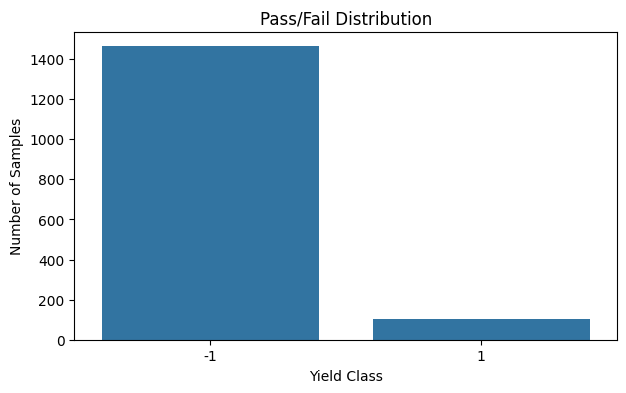

,Percentage
Pass/Fail,
-1,93.36
1,6.64


In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Pass/Fail")
plt.title("Pass/Fail Distribution")
plt.xlabel("Yield Class")
plt.ylabel("Number of Samples")
plt.show()

class_pct = df["Pass/Fail"].value_counts(normalize=True).mul(100)
display(class_pct.rename("Percentage").round(2).to_frame())


Since our target is strongly imbalanced an accuracy score can sometimes be misleading because a model can get high accuracy by mostly predicting Pass. For model tuning, F1-score for the Fail class is preferable, while accuracy, balanced accuracy, ROC-AUC and PR-AUC are also reported.

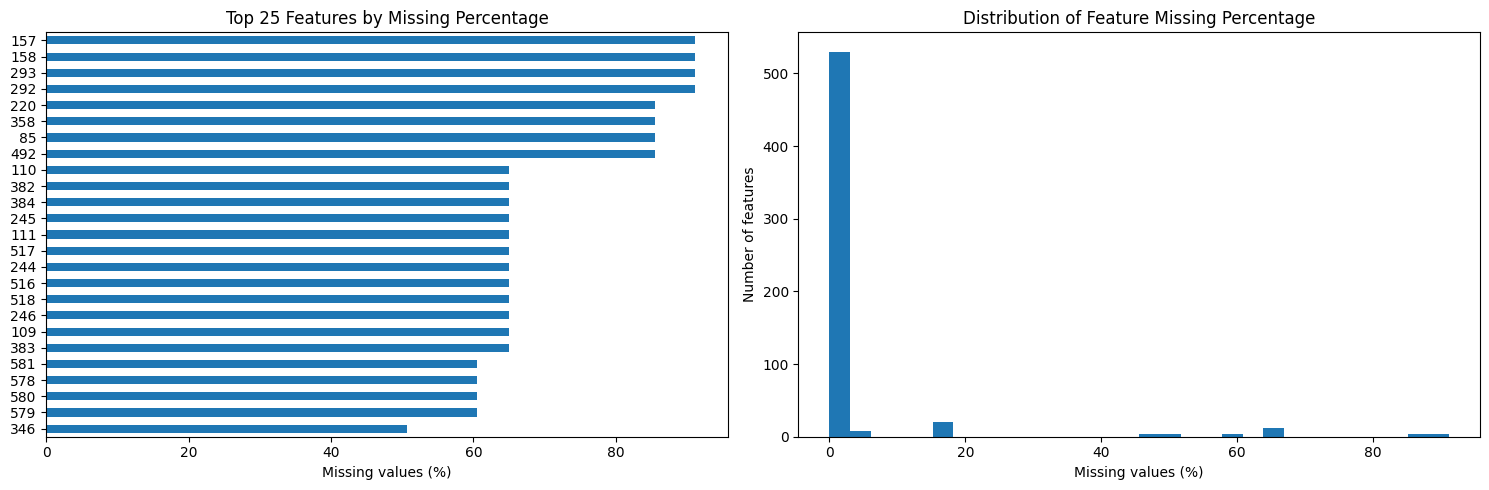

Features with missing values: 538
Features with >50% missing: 28


In [5]:
sensor_cols = [c for c in df.columns if c not in ["Time", "Pass/Fail"]]

missing = df[sensor_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

missing_pct.head(25).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 25 Features by Missing Percentage")
axes[0].set_xlabel("Missing values (%)")

axes[1].hist(missing_pct, bins=30)
axes[1].set_title("Distribution of Feature Missing Percentage")
axes[1].set_xlabel("Missing values (%)")
axes[1].set_ylabel("Number of features")

plt.tight_layout()
plt.show()

print("Features with missing values:", (missing > 0).sum())
print("Features with >50% missing:", (missing_pct > 50).sum())


## 2. Data cleansing and feature engineering

The raw timestamp is not directly useful to a classifier. Instead, useful parts of the timestamp are taken and used.

For sensor columns:
- features containing more than 50% missing values are taken out
- constant features are removed
- missing sensor values are later median-imputed inside the modelling pipeline
- row-level missing count is added as a simple process-quality feature

The 50% threshold is kind of a practical assumption since a signal observed in less than half of the production entities is unlikely to be reliable as a general purpose predictor.

In [6]:
data = df.copy()

data["Time"] = pd.to_datetime(data["Time"])
data["hour"] = data["Time"].dt.hour
data["dayofweek"] = data["Time"].dt.dayofweek
data["day"] = data["Time"].dt.day
data["month"] = data["Time"].dt.month

original_sensor_cols = [c for c in df.columns if c not in ["Time", "Pass/Fail"]]
data["missing_count"] = data[original_sensor_cols].isna().sum(axis=1)
data["missing_ratio"] = data["missing_count"] / len(original_sensor_cols)

data = data.drop(columns=["Time"])

X = data.drop(columns=["Pass/Fail"])
y = data["Pass/Fail"].map({-1: 0, 1: 1})

high_missing_cols = X.columns[X.isna().mean() > 0.50].tolist()
constant_cols = X.columns[X.nunique(dropna=True) <= 1].tolist()

X = X.drop(columns=high_missing_cols + constant_cols)

print("Original predictor count:", len(data.columns) - 1)
print("Removed for >50% missing:", len(high_missing_cols))
print("Removed constant features:", len(constant_cols))
print("Final predictor count:", X.shape[1])


Original predictor count: 596
Removed for >50% missing: 28
Removed constant features: 116
Final predictor count: 452


In [7]:
cleaning_summary = pd.DataFrame({
    "Step": [
        "Original predictors",
        "Removed >50% missing",
        "Removed constant",
        "Remaining predictors"
    ],
    "Number": [
        len(data.columns) - 1,
        len(high_missing_cols),
        len(constant_cols),
        X.shape[1]
    ]
})

display(cleaning_summary)


,Step,Number
0,Original predictors,596
1,Removed >50% missing,28
2,Removed constant,116
3,Remaining predictors,452


### To Check whether duplicate sensor columns remain

Since alot of duplicate sensor variables were found and the original dataset has alot of duplicate columns

In [8]:
duplicate_cols = X.T.duplicated()
duplicate_feature_names = X.columns[duplicate_cols].tolist()

print("Exact duplicate columns:", len(duplicate_feature_names))

if duplicate_feature_names:
    X = X.drop(columns=duplicate_feature_names)

print("Predictors after duplicate removal:", X.shape[1])


Exact duplicate columns: 0
Predictors after duplicate removal: 452


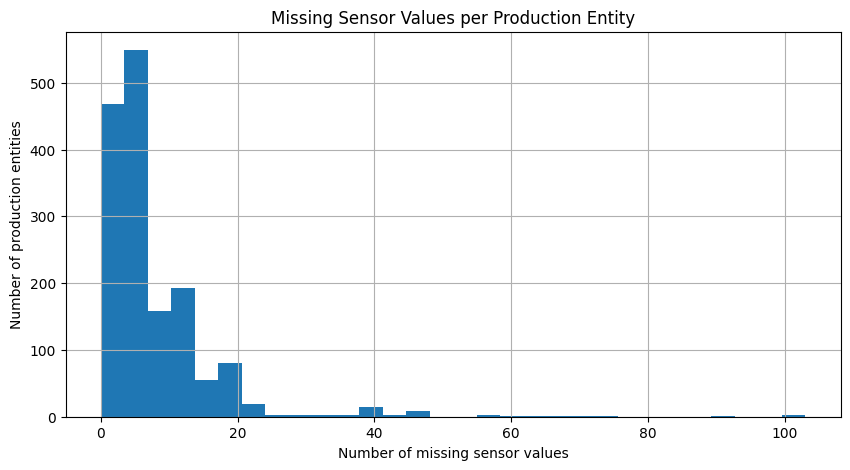

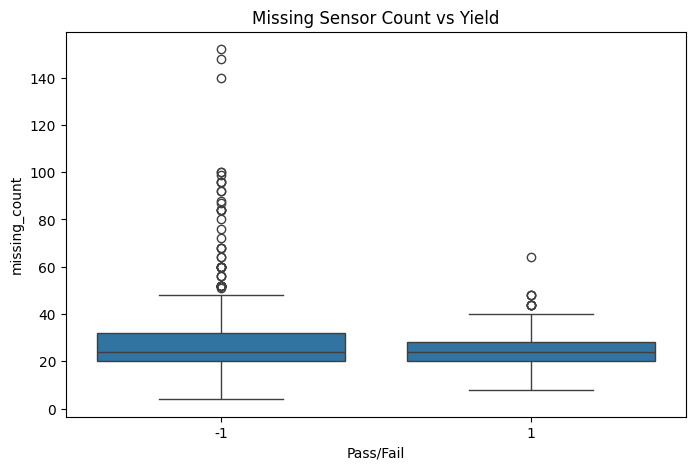

,mean,median,min,max
Pass/Fail,,,,
-1,26.86,24.0,4,152
1,25.46,24.0,8,64


In [9]:
plt.figure(figsize=(10, 5))
X.isna().sum(axis=1).hist(bins=30)
plt.title("Missing Sensor Values per Production Entity")
plt.xlabel("Number of missing sensor values")
plt.ylabel("Number of production entities")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Pass/Fail", y="missing_count")
plt.title("Missing Sensor Count vs Yield")
plt.show()

display(
    data.groupby("Pass/Fail")["missing_count"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)


## 3. Univariate analysis

first we try to understand individual sensor distributions. Sensor scales are very different, so the plots are mainly used to detect skewness, extreme values and unusual measurement ranges.

In [10]:
feature_stats = X.describe().T
feature_stats["missing_pct"] = X.isna().mean() * 100
feature_stats["skew"] = X.skew(numeric_only=True)

display(feature_stats.sort_values("std", ascending=False).head(20))


,count,mean,std,min,25%,50%,75%,max,missing_pct,skew
162,1565.0,4797.154633,6553.569317,0.0000,451.000000,1784.0000,6384.0000,36871.0000,0.127632,1.828761
161,1565.0,4066.850479,4239.245058,0.0000,1321.000000,2614.0000,5034.0000,37943.0000,0.127632,2.229785
297,1565.0,2342.826978,3226.924298,0.0000,210.936600,820.0988,3190.6164,18520.4683,0.127632,1.790486
24,1565.0,-298.598136,2902.690117,-14804.5000,-1476.000000,-78.7500,1377.2500,14106.0000,0.127632,-0.054091
296,1565.0,1879.228369,1975.111365,0.0000,603.032900,1202.4121,2341.2887,15559.9525,0.127632,2.189508
23,1565.0,-3806.299734,1380.162148,-9986.7500,-4371.750000,-3820.7500,-3352.7500,2363.0000,0.127632,0.356647
159,1565.0,882.680511,983.043021,0.0000,411.000000,623.0000,966.0000,7791.0000,0.127632,4.203623
21,1565.0,-5618.393610,626.822178,-7150.2500,-5933.250000,-5523.2500,-5356.2500,0.0000,0.127632,2.374624
160,1565.0,555.346326,574.808588,0.0000,295.000000,438.0000,625.0000,4170.0000,0.127632,3.993205
204,1561.0,32.218169,565.101239,0.0429,0.114300,0.1582,0.2307,9998.4483,0.382897,17.601091


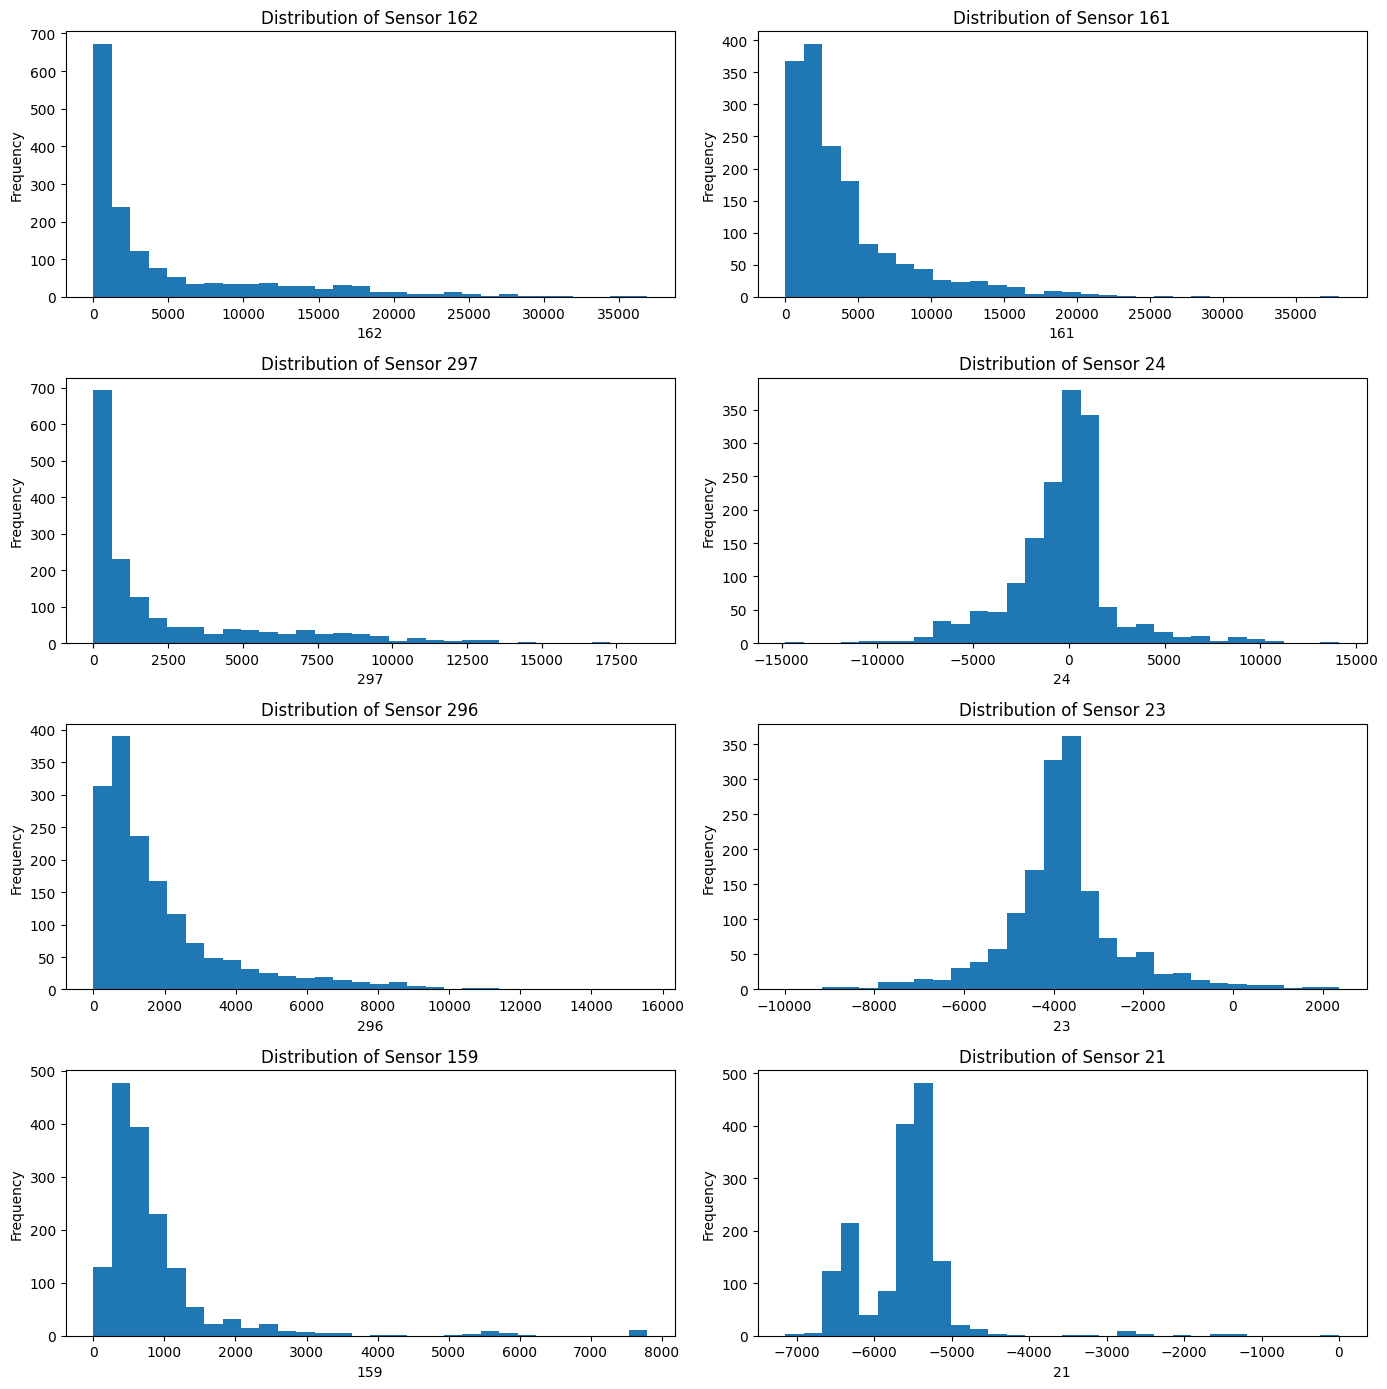

In [11]:
top_variance = X.var(numeric_only=True).sort_values(ascending=False).head(8).index

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for ax, col in zip(axes.ravel(), top_variance):
    ax.hist(X[col].dropna(), bins=30)
    ax.set_title(f"Distribution of Sensor {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [12]:
median_filled = X.fillna(X.median(numeric_only=True))
target_corr = median_filled.corrwith(y).abs().sort_values(ascending=False)

top_corr_features = target_corr.head(12).index.tolist()

display(
    pd.DataFrame({
        "Feature": top_corr_features,
        "Absolute correlation": target_corr.loc[top_corr_features].values
    })
)


,Feature,Absolute correlation
0,59,0.156008
1,103,0.151230
2,510,0.131662
3,348,0.130807
4,431,0.119936
5,434,0.111312
6,430,0.109115
7,21,0.108333
8,435,0.108260
9,28,0.106987


The correlation ranking is only an initial screening method. A low individual correlation does not necessarily mean that a feature is useless because nonlinear and multivariate relationships can exist.

## 4. Bivariate analysis

The following plots compare important individual sensor signals with the Pass/Fail target.

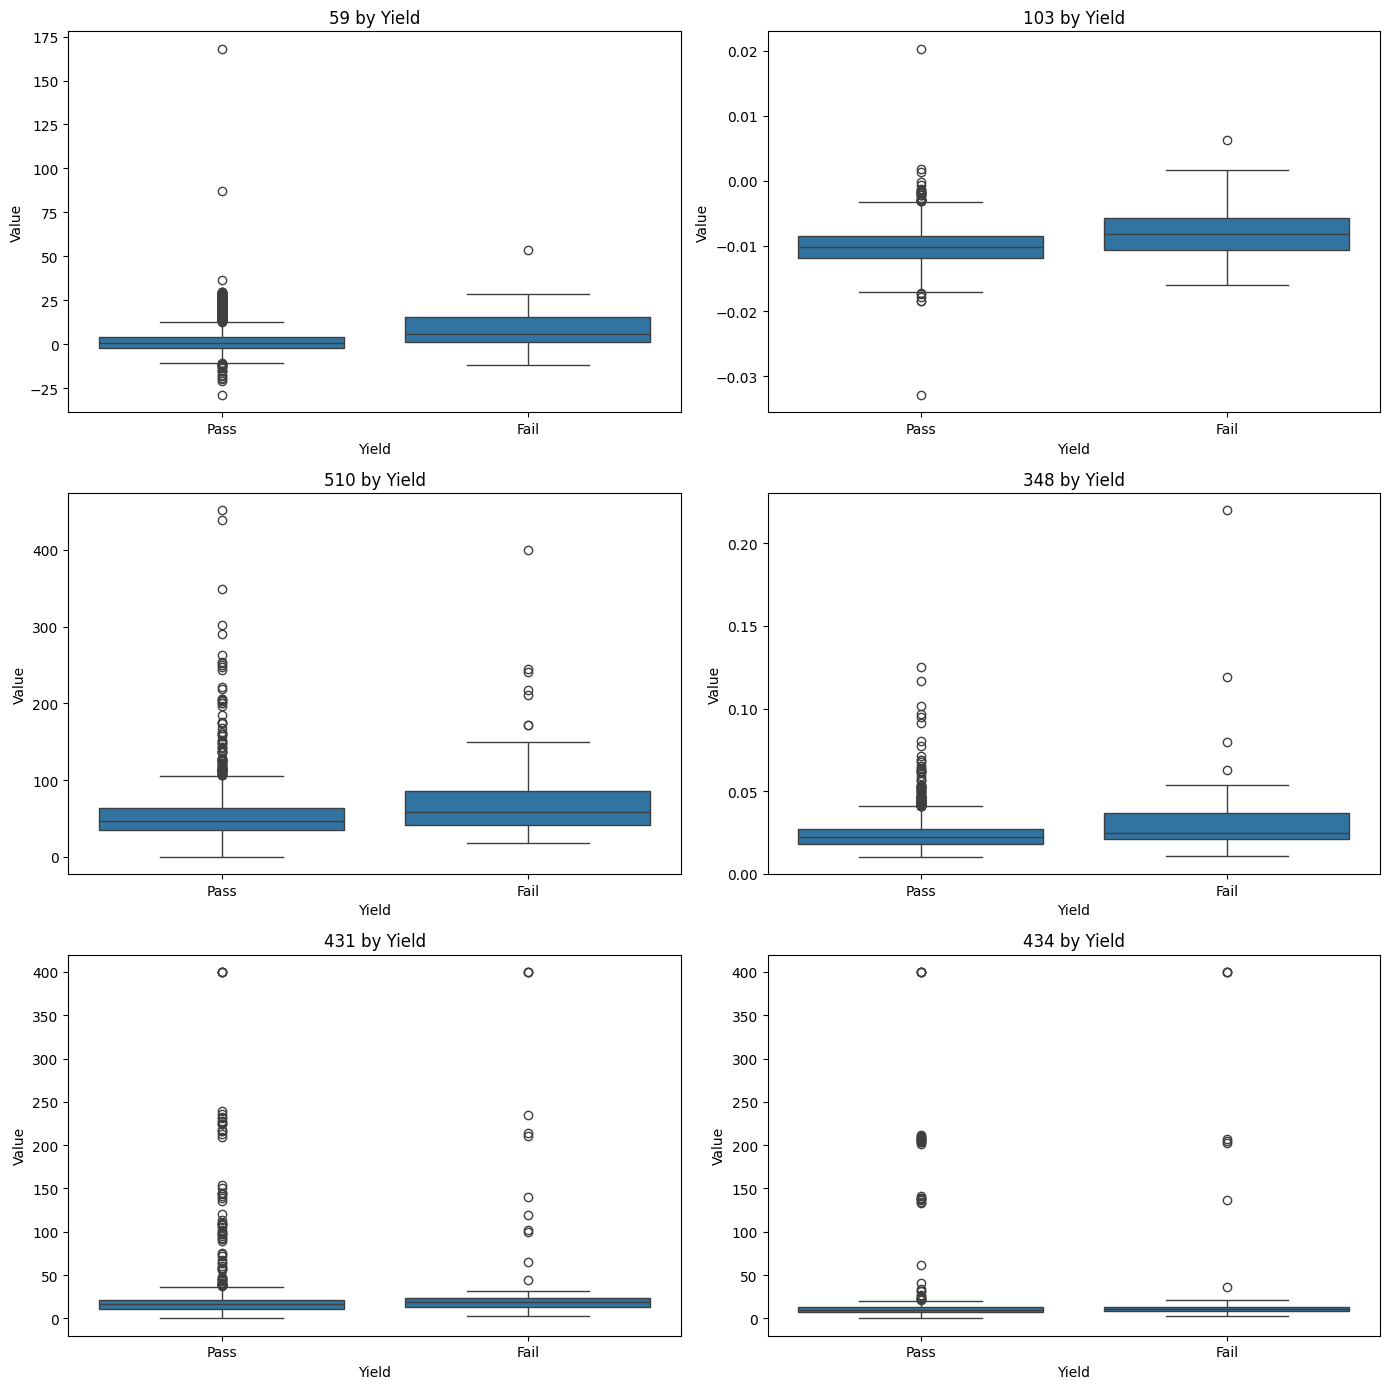

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for ax, col in zip(axes.ravel(), top_corr_features[:6]):
    sns.boxplot(data=pd.DataFrame({
        "Yield": y.map({0: "Pass", 1: "Fail"}),
        "Value": X[col]
    }), x="Yield", y="Value", ax=ax)
    ax.set_title(f"{col} by Yield")

plt.tight_layout()
plt.show()


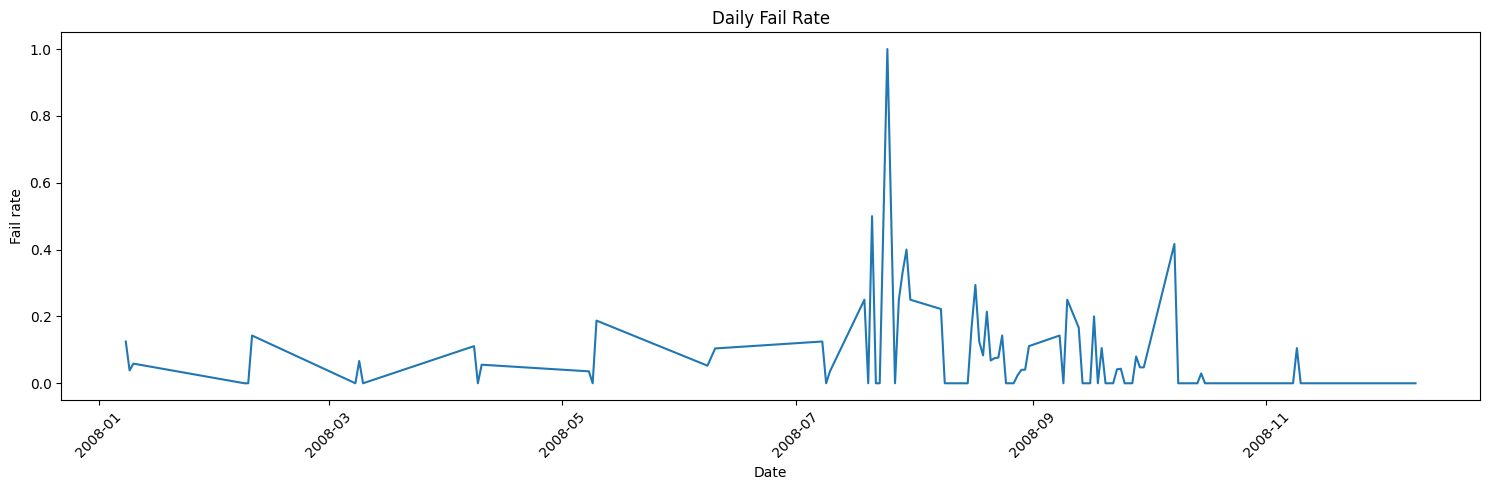

In [14]:
time_data = data.copy()
time_data["date"] = pd.to_datetime(
    df["Time"]
).dt.date

daily_fail_rate = (
    time_data.groupby("date")["Pass/Fail"]
    .apply(lambda x: (x == 1).mean())
)

plt.figure(figsize=(15, 5))
daily_fail_rate.plot()
plt.title("Daily Fail Rate")
plt.xlabel("Date")
plt.ylabel("Fail rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


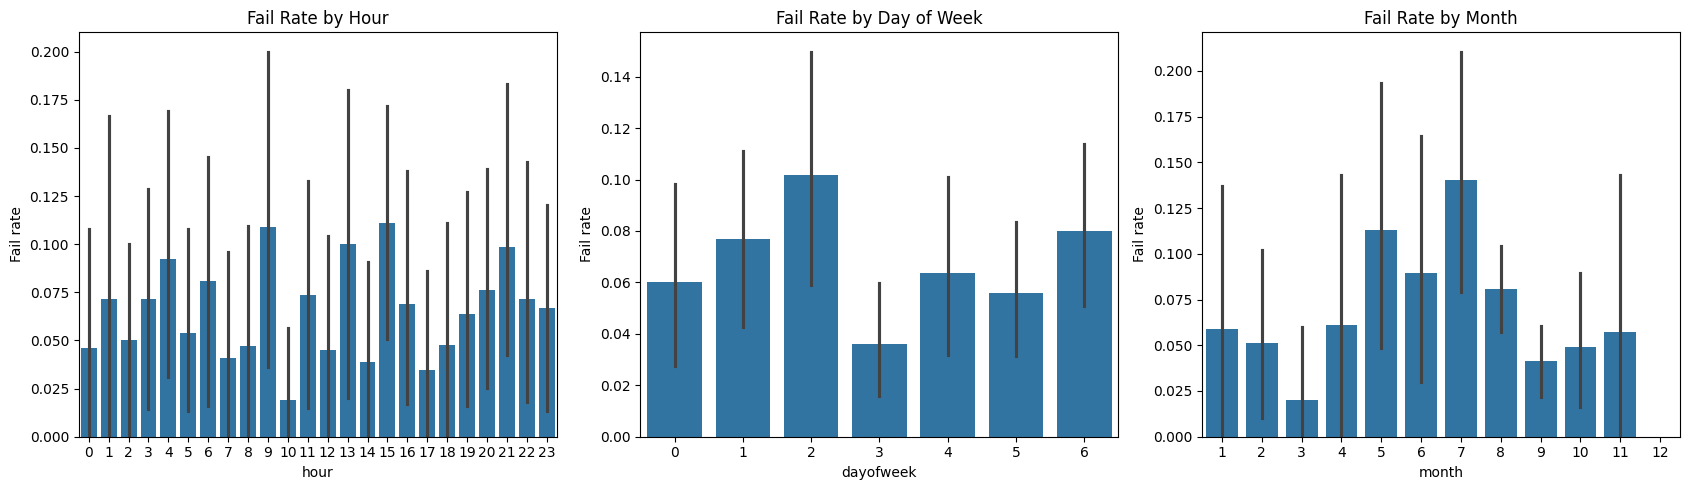

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.barplot(
    data=data.assign(Yield=y.map({0: "Pass", 1: "Fail"})),
    x="hour",
    y="Pass/Fail",
    ax=axes[0],
    estimator=lambda x: (x == 1).mean()
)
axes[0].set_title("Fail Rate by Hour")
axes[0].set_ylabel("Fail rate")

sns.barplot(
    data=data.assign(Yield=y.map({0: "Pass", 1: "Fail"})),
    x="dayofweek",
    y="Pass/Fail",
    ax=axes[1],
    estimator=lambda x: (x == 1).mean()
)
axes[1].set_title("Fail Rate by Day of Week")
axes[1].set_ylabel("Fail rate")

sns.barplot(
    data=data.assign(Yield=y.map({0: "Pass", 1: "Fail"})),
    x="month",
    y="Pass/Fail",
    ax=axes[2],
    estimator=lambda x: (x == 1).mean()
)
axes[2].set_title("Fail Rate by Month")
axes[2].set_ylabel("Fail rate")

plt.tight_layout()
plt.show()


## 5. Multivariate analysis

Sensor measurements can be strongly correlated with each other. A correlation heatmap helps identify groups of redundant signals.

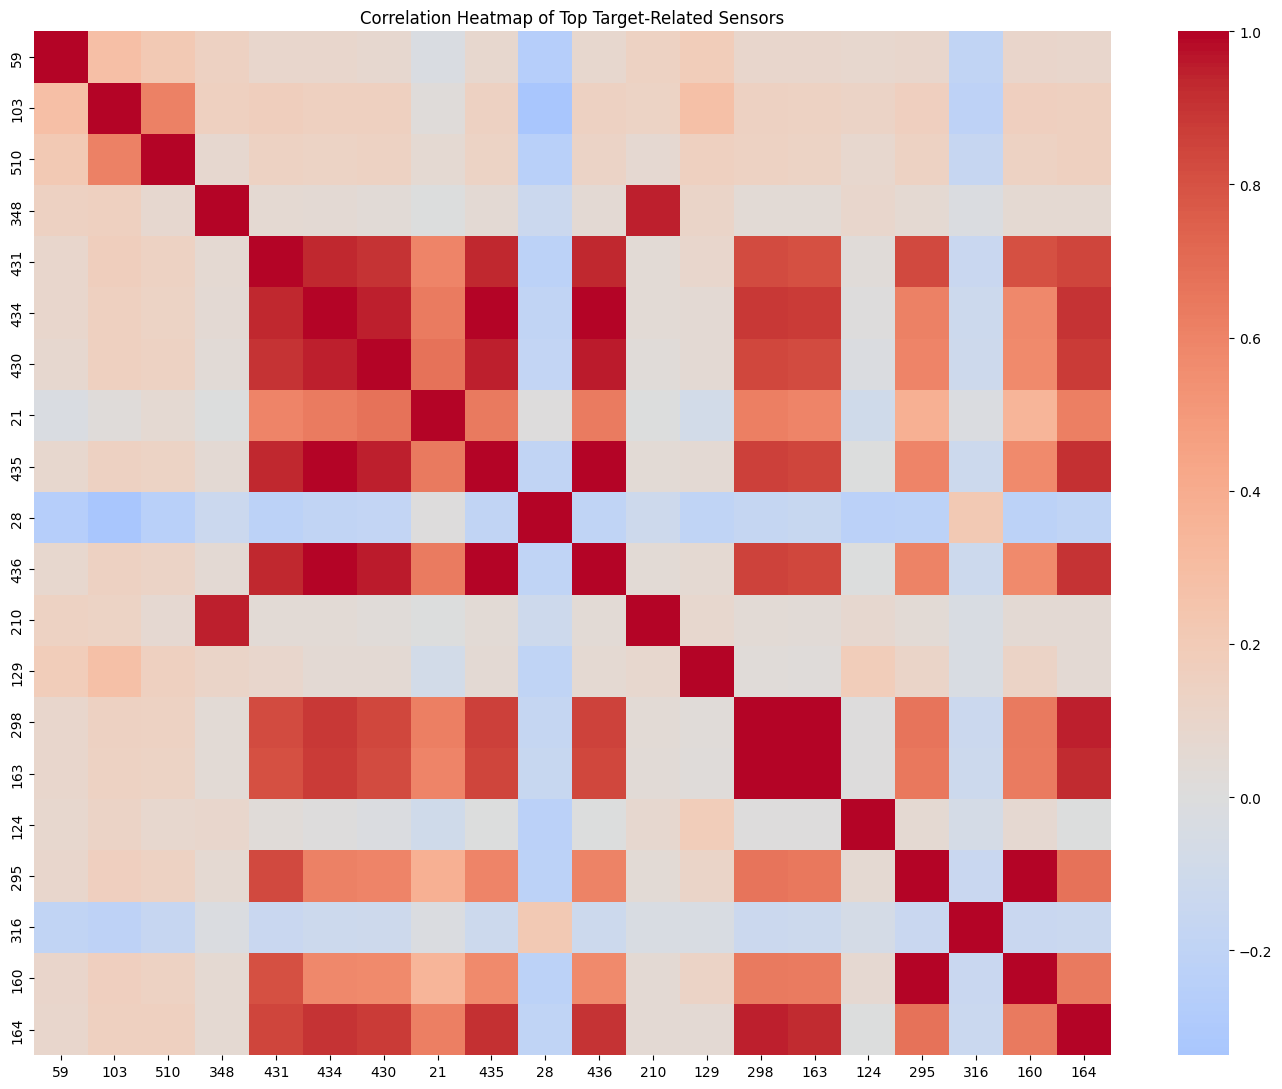

In [16]:
corr_features = target_corr.head(20).index
corr_matrix = median_filled[corr_features].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Top Target-Related Sensors")
plt.tight_layout()
plt.show()


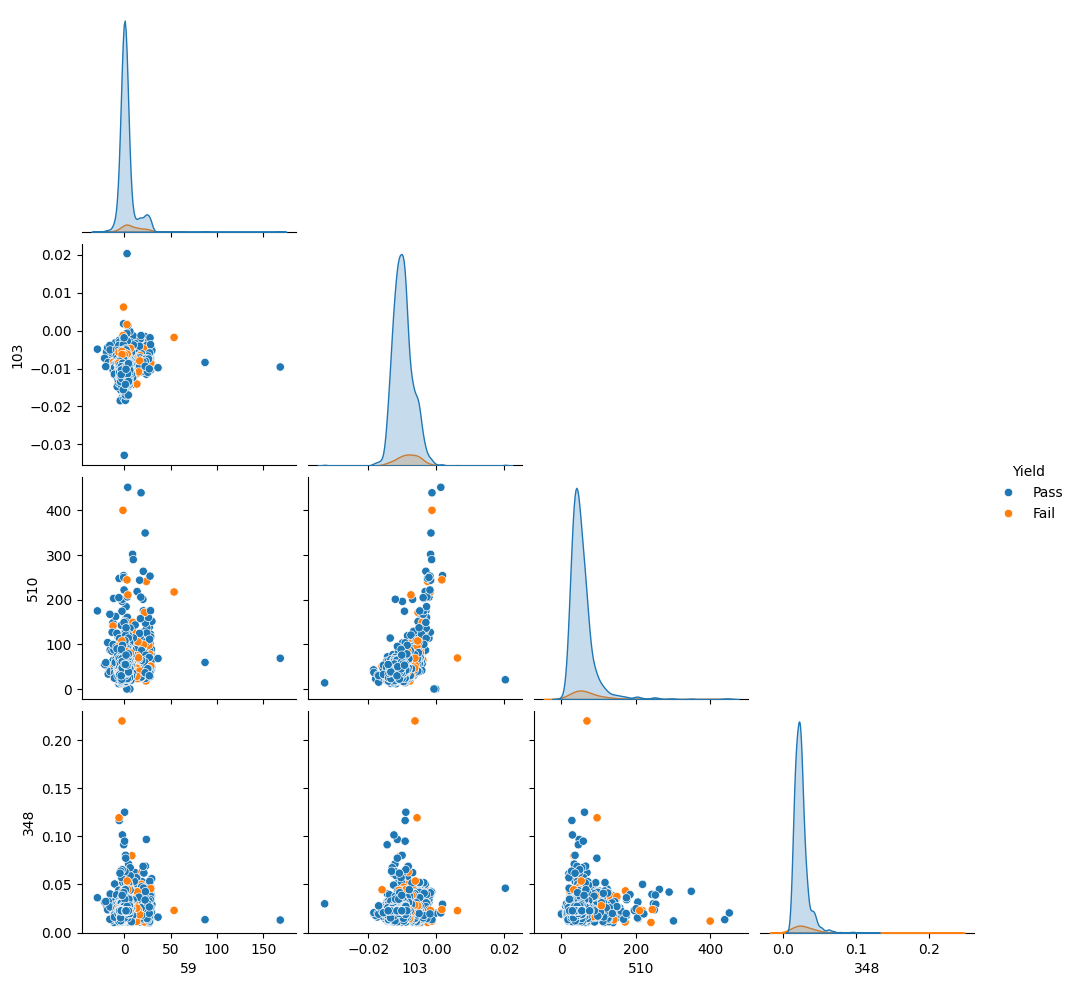

In [17]:
pair_features = top_corr_features[:4]

pair_data = median_filled[pair_features].copy()
pair_data["Yield"] = y.map({0: "Pass", 1: "Fail"})

sns.pairplot(pair_data, hue="Yield", corner=True)
plt.show()


## 6. Train-test split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

split_check = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).rename(index={0: "Pass", 1: "Fail"})

display((split_check * 100).round(2))


Train shape: (1253, 452)
Test shape: (314, 452)


,Original,Train,Test
Pass/Fail,,,
Pass,93.36,93.38,93.31
Fail,6.64,6.62,6.69


In [19]:
train_stats = X_train.describe().T[["mean", "std"]].rename(
    columns={"mean": "train_mean", "std": "train_std"}
)

test_stats = X_test.describe().T[["mean", "std"]].rename(
    columns={"mean": "test_mean", "std": "test_std"}
)

stats_compare = train_stats.join(test_stats)
stats_compare["mean_difference"] = (
    stats_compare["train_mean"] - stats_compare["test_mean"]
).abs()

display(stats_compare["mean_difference"].describe())


,mean_difference
count,4.520000e+02
mean,1.897313e+00
std,7.291289e+00
min,7.107504e-07
25%,1.318453e-03
50%,3.076092e-02
75%,3.851139e-01
max,6.154240e+01


## 7. Pre-processing and dimensionality reduction

Two main approaches:

1. **SelectKBest + ANOVA F-test** – this keeps the most target relevant sensor signals
2. **PCA** – transforming orginal sensor set to a smaller set while keeping max variance

SMOTE is only applied in training pipeline. Generating synthetic signals can lead to disruption.

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [21]:
model_grids = {}

model_grids["Logistic Regression"] = (
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_classif)),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=3000))
    ]),
    {
        "selector__k": [50, 100, 200],
        "model__C": [0.1, 1, 10]
    }
)

model_grids["SVM"] = (
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_classif)),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", SVC(probability=True))
    ]),
    {
        "selector__k": [50, 100, 200],
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf"],
        "model__gamma": ["scale"]
    }
)

model_grids["Random Forest"] = (
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_classif)),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]),
    {
        "selector__k": [50, 100, 200],
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10],
        "model__min_samples_leaf": [1, 2]
    }
)

model_grids["Naive Bayes"] = (
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_classif)),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", GaussianNB())
    ]),
    {
        "selector__k": [50, 100, 200],
        "model__var_smoothing": [1e-9, 1e-8, 1e-7]
    }
)

model_grids["PCA + SVM"] = (
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=42)),
        ("smote", SMOTE(random_state=42)),
        ("model", SVC(probability=True))
    ]),
    {
        "pca__n_components": [0.80, 0.90, 0.95],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    }
)


### Why F1 is used for tuning

Only about 6.6% of the observations are Fail. Optimising only accuracy can result in a model that predicts Pass for almost everything.

Therefore we ise **F1-score of the Fail class** as its main tuning metric. Still keeping accuracy as part of the project requirement


In [22]:
grid_results = {}

for name, (pipe, params) in model_grids.items():
    print("Training:", name)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train, y_train)

    grid_results[name] = search

    print("Best CV F1:", round(search.best_score_, 4))
    print("Best parameters:", search.best_params_)
    print()


Training: Logistic Regression
Best CV F1: 0.2128
Best parameters: {'model__C': 0.1, 'selector__k': 200}

Training: SVM
Best CV F1: 0.2019
Best parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'selector__k': 200}

Training: Random Forest
Best CV F1: 0.2309
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200, 'selector__k': 200}

Training: Naive Bayes
Best CV F1: 0.1275
Best parameters: {'model__var_smoothing': 1e-09, 'selector__k': 200}

Training: PCA + SVM
Best CV F1: 0.1579
Best parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'pca__n_components': 0.9}



## 8. Model evaluation

We are using the following metrics:
- Accuracy
- Precision
- Recall
- F1
- Balanced accuracy
- ROC-AUC
- PR-AUC

In [23]:
model_metrics = []

for name, search in grid_results.items():
    model = search.best_estimator_

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    model_metrics.append({
        "Model": name,
        "CV F1": search.best_score_,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, zero_division=0),
        "Recall": recall_score(y_test, test_pred, zero_division=0),
        "F1": f1_score(y_test, test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_prob),
        "PR-AUC": average_precision_score(y_test, test_prob)
    })

results_df = pd.DataFrame(model_metrics).sort_values("CV F1", ascending=False)
display(results_df.round(4))


,Model,CV F1,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Random Forest,0.2309,0.9984,0.9236,0.5170,0.2000,0.0476,0.0769,0.7570,0.1999
0,Logistic Regression,0.2128,0.8731,0.7994,0.5167,0.0800,0.1905,0.1127,0.6108,0.1312
1,SVM,0.2019,0.8827,0.8535,0.5458,0.1212,0.1905,0.1481,0.5906,0.1017
4,PCA + SVM,0.1579,0.9138,0.8439,0.5185,0.0882,0.1429,0.1091,0.5553,0.0961
3,Naive Bayes,0.1275,0.8859,0.8854,0.6512,0.2581,0.3810,0.3077,0.7237,0.1980


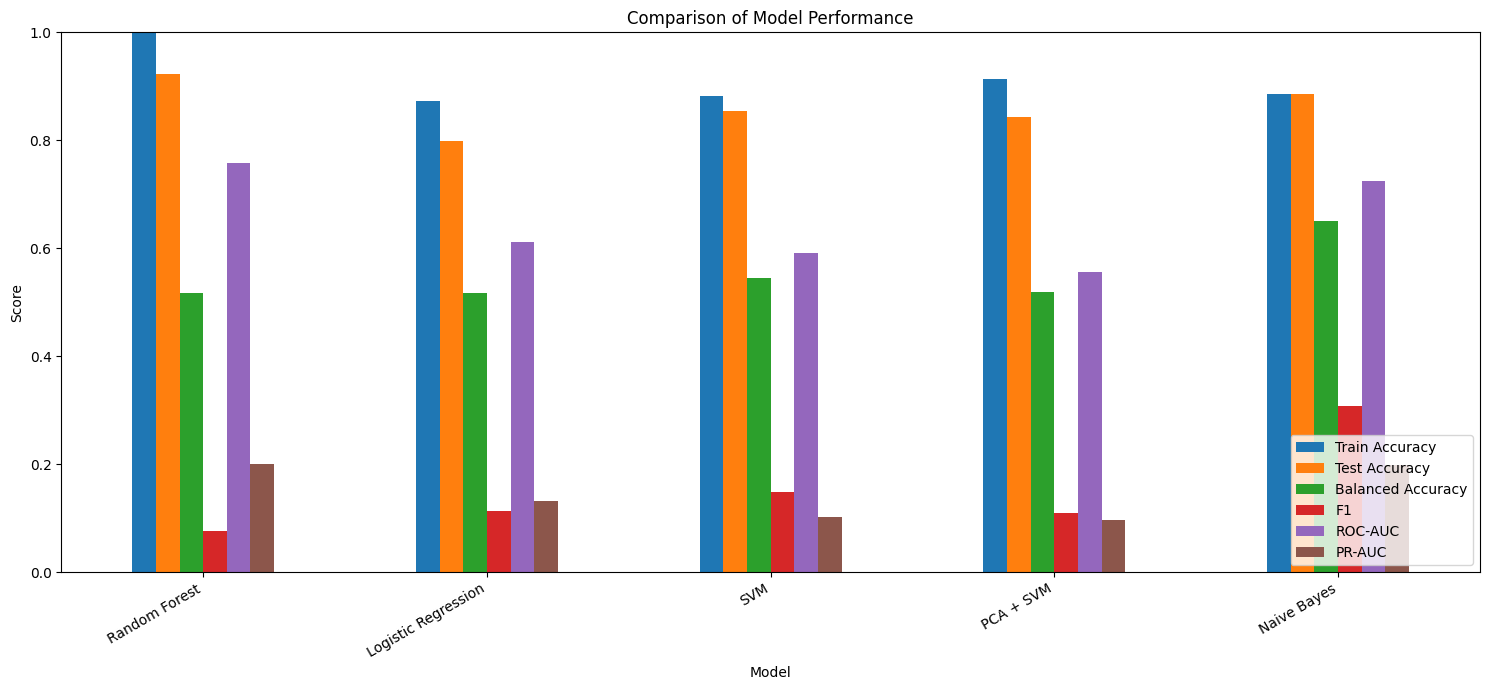

In [24]:
plot_df = results_df.set_index("Model")[[
    "Train Accuracy",
    "Test Accuracy",
    "Balanced Accuracy",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]]

plot_df.plot(kind="bar", figsize=(15, 7))
plt.title("Comparison of Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


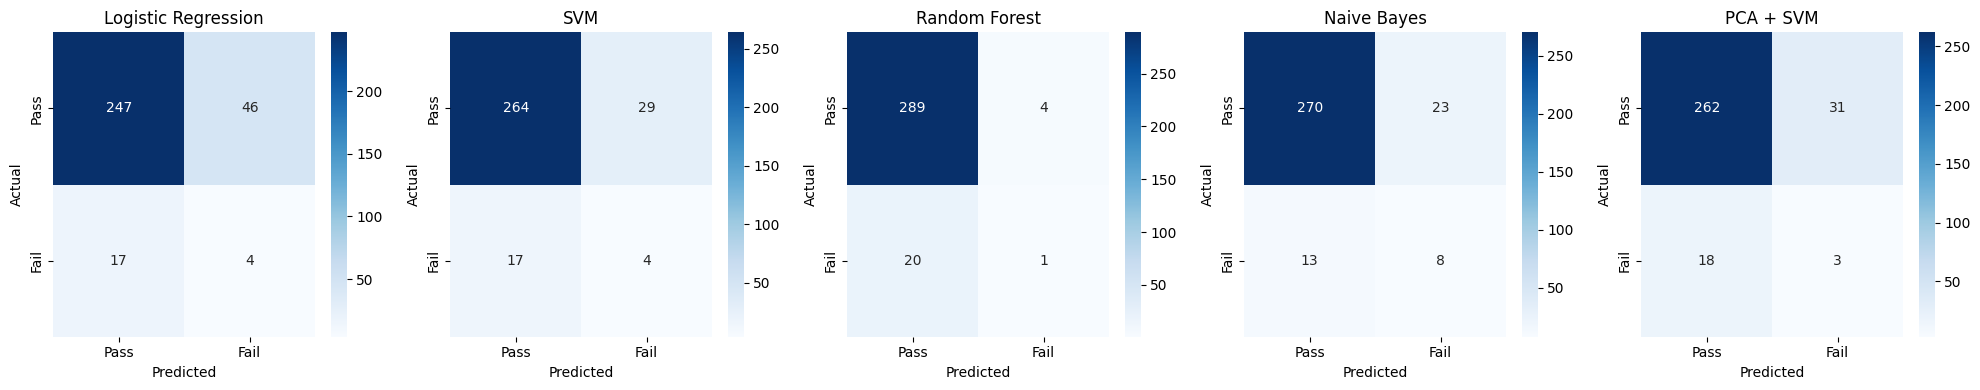

In [25]:
fig, axes = plt.subplots(1, len(grid_results), figsize=(20, 4))

for ax, (name, search) in zip(axes, grid_results.items()):
    pred = search.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Pass", "Fail"],
        yticklabels=["Pass", "Fail"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [26]:
for name, search in grid_results.items():
    pred = search.best_estimator_.predict(X_test)

    print("=" * 70)
    print(name)
    print(classification_report(
        y_test,
        pred,
        target_names=["Pass", "Fail"],
        digits=4,
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

        Pass     0.9356    0.8430    0.8869       293
        Fail     0.0800    0.1905    0.1127        21

    accuracy                         0.7994       314
   macro avg     0.5078    0.5167    0.4998       314
weighted avg     0.8784    0.7994    0.8351       314

SVM
              precision    recall  f1-score   support

        Pass     0.9395    0.9010    0.9199       293
        Fail     0.1212    0.1905    0.1481        21

    accuracy                         0.8535       314
   macro avg     0.5304    0.5458    0.5340       314
weighted avg     0.8848    0.8535    0.8682       314

Random Forest
              precision    recall  f1-score   support

        Pass     0.9353    0.9863    0.9601       293
        Fail     0.2000    0.0476    0.0769        21

    accuracy                         0.9236       314
   macro avg     0.5676    0.5170    0.5185       314
weighted avg     0.8861    0.9236   

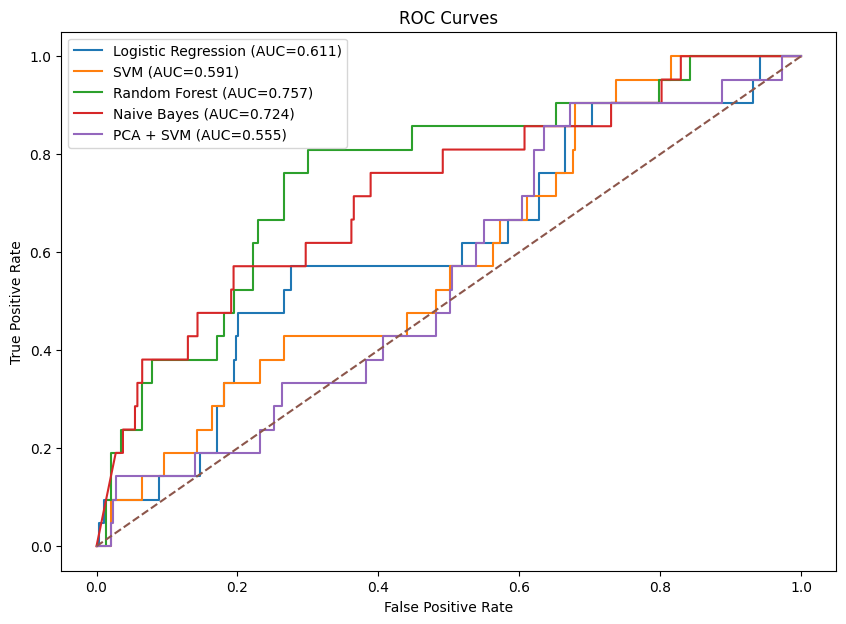

In [27]:
plt.figure(figsize=(10, 7))

for name, search in grid_results.items():
    model = search.best_estimator_
    prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


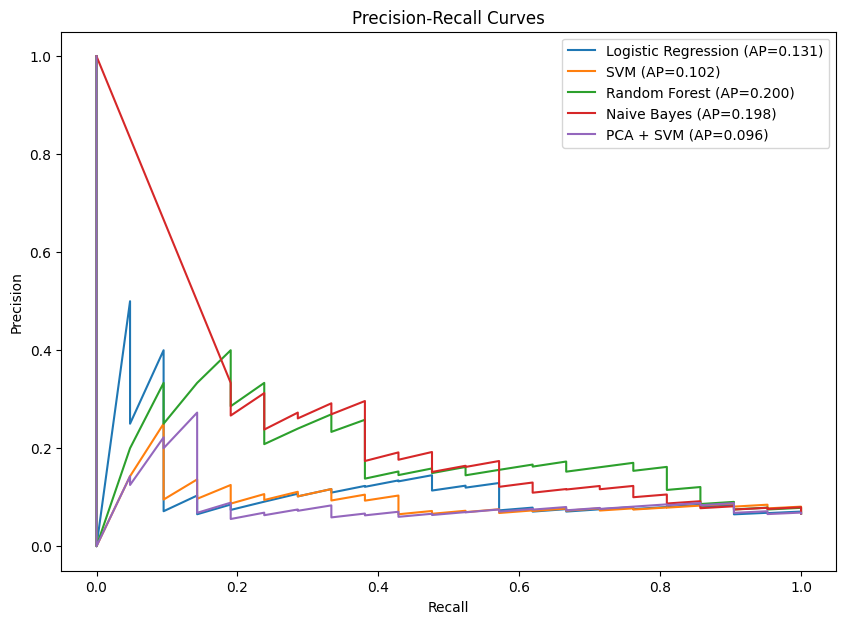

In [28]:
plt.figure(figsize=(10, 7))

for name, search in grid_results.items():
    model = search.best_estimator_
    prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()


## 9. PCA analysis

Examining PCA independently to track how many components explain most signal errors

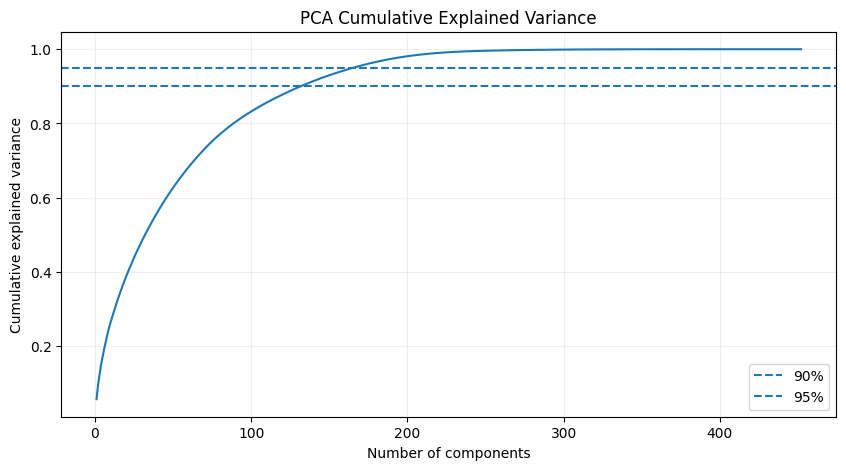

Components for 90% variance: 132
Components for 95% variance: 166


In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pca_input = SimpleImputer(strategy="median").fit_transform(X)
pca_input = StandardScaler().fit_transform(pca_input)

pca_full = PCA().fit(pca_input)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Components for 90% variance:",
      np.argmax(cumulative_variance >= 0.90) + 1)

print("Components for 95% variance:",
      np.argmax(cumulative_variance >= 0.95) + 1)


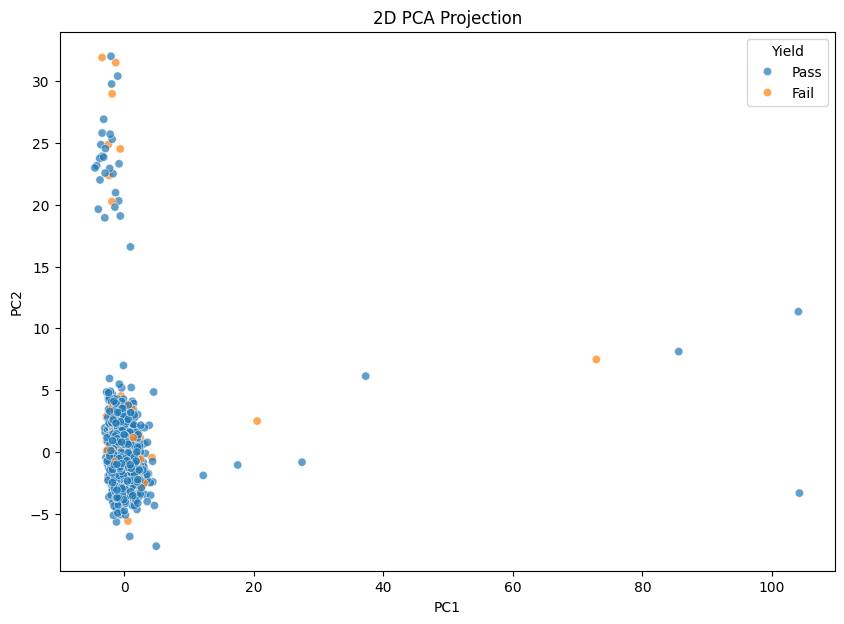

In [30]:
pca_2d = PCA(n_components=2)
pca_values = pca_2d.fit_transform(pca_input)

pca_plot = pd.DataFrame({
    "PC1": pca_values[:, 0],
    "PC2": pca_values[:, 1],
    "Yield": y.map({0: "Pass", 1: "Fail"})
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="Yield",
    alpha=0.7
)
plt.title("2D PCA Projection")
plt.show()


## 10. Important signal identification

Using feature selection to find the sensor signals with most effect on Pass/Fail result.

Also using Random Forest feature importance to figure out the signals more useful for prediction.

In [31]:
selector_model = grid_results["SVM"].best_estimator_

selector = selector_model.named_steps["selector"]
scores = pd.Series(
    selector.scores_,
    index=X_train.columns
).sort_values(ascending=False)

selected_features = selector.get_feature_names_out()

print("Number of selected SVM features:", len(selected_features))

display(
    scores.head(30).to_frame("ANOVA F-score")
)


Number of selected SVM features: 200


,ANOVA F-score
103,38.345328
510,26.408693
59,20.145968
348,15.719980
129,14.664044
431,14.090072
64,13.675521
21,12.463758
125,11.306550
430,10.875200


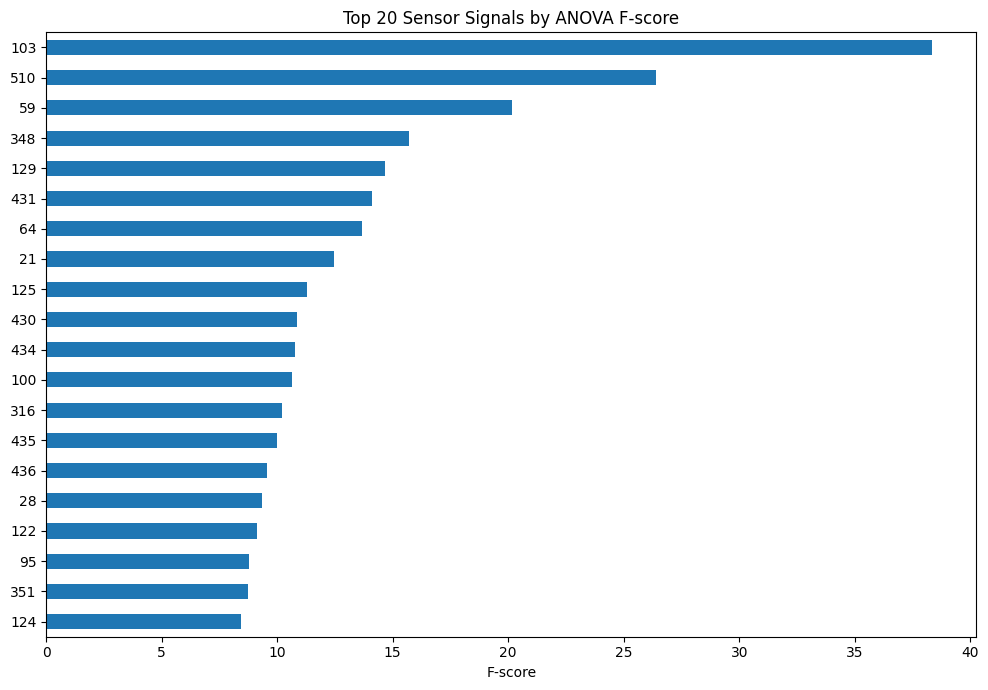

In [32]:
plt.figure(figsize=(10, 7))
scores.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Sensor Signals by ANOVA F-score")
plt.xlabel("F-score")
plt.tight_layout()
plt.show()


,Random Forest importance
x203,0.035623
x298,0.031591
x390,0.029436
x54,0.023859
x31,0.022895
x93,0.022669
x388,0.020842
x86,0.019994
x164,0.016020
x29,0.014804


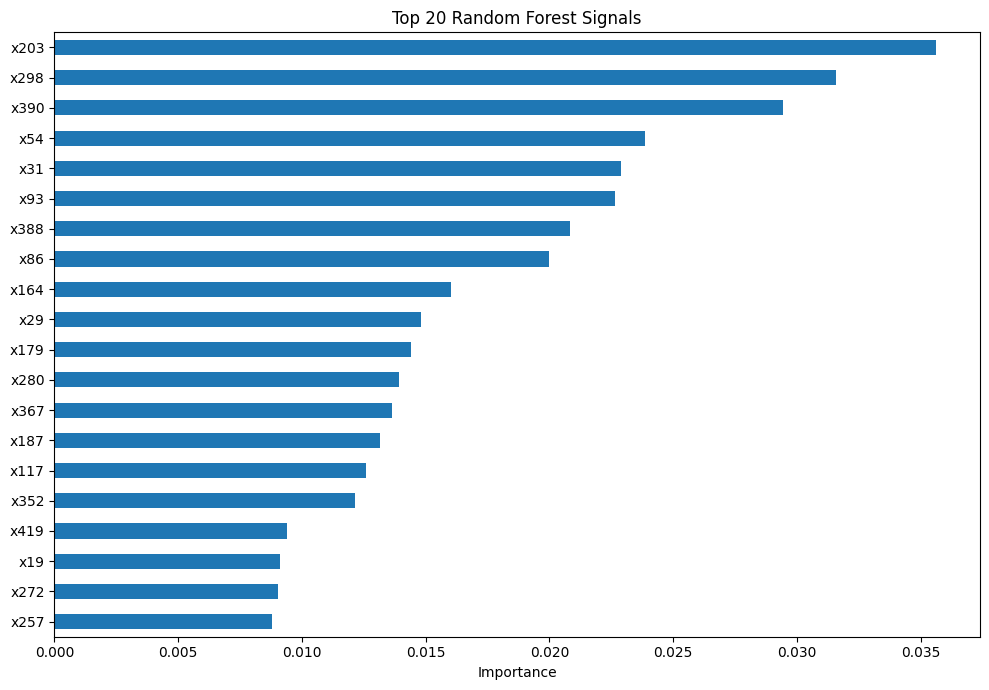

In [33]:
rf_model = grid_results["Random Forest"].best_estimator_
rf_selector = rf_model.named_steps["selector"]
rf = rf_model.named_steps["model"]

rf_features = rf_selector.get_feature_names_out()

rf_importance = pd.Series(
    rf.feature_importances_,
    index=rf_features
).sort_values(ascending=False)

display(rf_importance.head(20).to_frame("Random Forest importance"))

plt.figure(figsize=(10, 7))
rf_importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Random Forest Signals")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


,Permutation importance
129,0.036783
14,0.035763
362,0.034941
247,0.034070
28,0.033568
224,0.027952
90,0.027587
125,0.027517
68,0.027437
124,0.026629


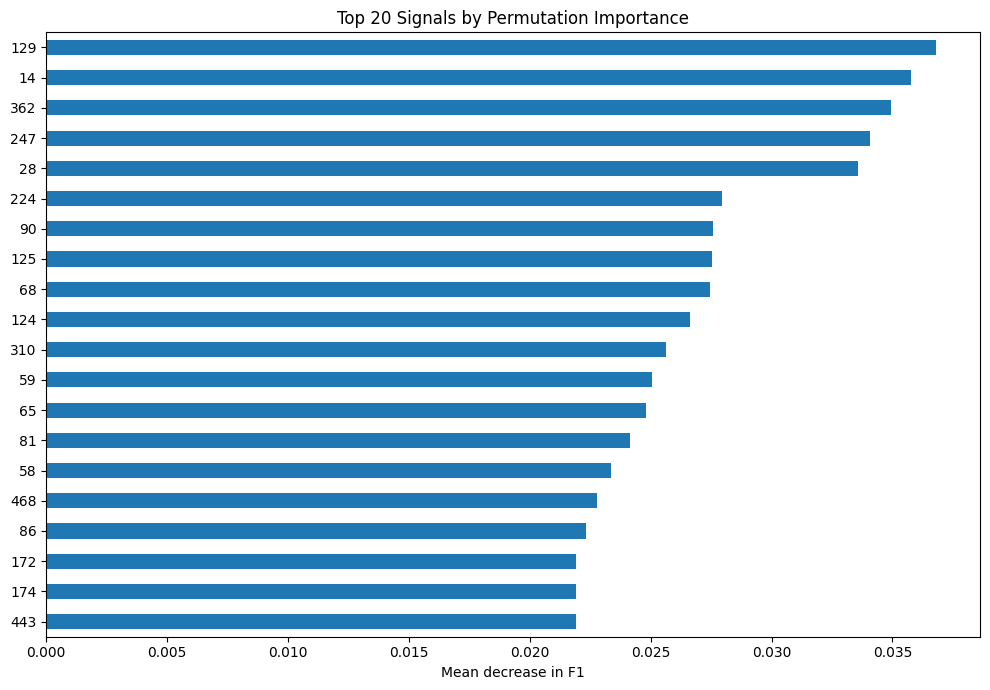

In [34]:
from sklearn.inspection import permutation_importance

svm_model = grid_results["SVM"].best_estimator_

perm = permutation_importance(
    svm_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_scores = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

display(perm_scores.head(20).to_frame("Permutation importance"))

plt.figure(figsize=(10, 7))
perm_scores.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Signals by Permutation Importance")
plt.xlabel("Mean decrease in F1")
plt.tight_layout()
plt.show()


## 11. Feature-count experiment

The main question of the project is whether all signals are necessary. The tuned SVM is therefore compared using different numbers of selected features.

If performance remains similar after reducing hundreds of signals to a much smaller set, the removed signals are not necessary for this predictive task.

In [35]:
feature_count_results = []

for k in [20, 50, 100, 200, 300]:
    pipe = ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=f_classif, k=k)),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", SVC(
            C=grid_results["SVM"].best_params_["model__C"],
            kernel="rbf",
            gamma="scale",
            probability=True
        ))
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    feature_count_results.append({
        "Features": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

feature_count_df = pd.DataFrame(feature_count_results)
display(feature_count_df.round(4))


,Features,Accuracy,Balanced Accuracy,F1,ROC-AUC,PR-AUC
0,20,0.7771,0.7258,0.2857,0.8017,0.2391
1,50,0.7675,0.7207,0.2772,0.7613,0.1925
2,100,0.7803,0.5728,0.1687,0.7143,0.1266
3,200,0.8535,0.5458,0.1481,0.5901,0.1017
4,300,0.8726,0.5339,0.1304,0.5849,0.1032


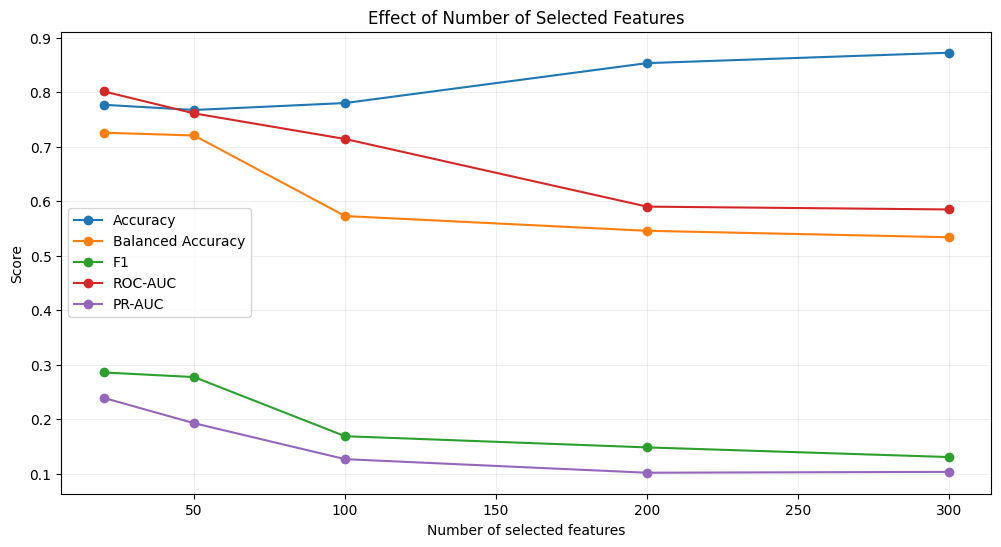

In [36]:
feature_count_df.set_index("Features")[[
    "Accuracy",
    "Balanced Accuracy",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]].plot(marker="o", figsize=(12, 6))

plt.title("Effect of Number of Selected Features")
plt.xlabel("Number of selected features")
plt.ylabel("Score")
plt.grid(alpha=0.2)
plt.show()


## 12. Final model selection

We select the final model using cross-validation F1 but the model can still be chosen depending on what metrics you are looking for as result.

In [37]:
best_name = results_df.iloc[0]["Model"]
best_model = grid_results[best_name].best_estimator_

print("Selected model:", best_name)
print("Best CV F1:", round(grid_results[best_name].best_score_, 4))
print("Best parameters:")
display(grid_results[best_name].best_params_)

final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)[:, 1]

final_results = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_prob),
    "PR-AUC": average_precision_score(y_test, final_prob)
}

display(pd.DataFrame(final_results, index=["Final Model"]).round(4))


Selected model: Random Forest
Best CV F1: 0.2309
Best parameters:


{'model__max_depth': 10,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 200,
 'selector__k': 200}

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Final Model,0.9236,0.517,0.2,0.0476,0.0769,0.757,0.1999


### Final classification report

              precision    recall  f1-score   support

        Pass     0.9353    0.9863    0.9601       293
        Fail     0.2000    0.0476    0.0769        21

    accuracy                         0.9236       314
   macro avg     0.5676    0.5170    0.5185       314
weighted avg     0.8861    0.9236    0.9011       314



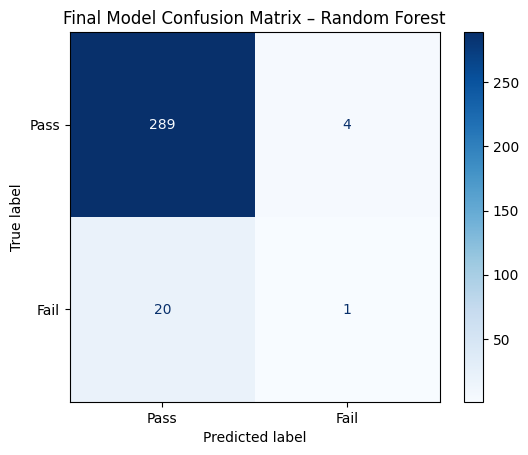

In [38]:
print(classification_report(
    y_test,
    final_pred,
    target_names=["Pass", "Fail"],
    digits=4,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["Pass", "Fail"],
    cmap="Blues"
)
plt.title(f"Final Model Confusion Matrix – {best_name}")
plt.show()


## 13. Save the model


In [39]:
preprocessing_info = {
    "high_missing_cols": high_missing_cols,
    "constant_cols": constant_cols,
    "duplicate_feature_names": duplicate_feature_names,
    "final_feature_columns": X.columns.tolist(),
    "target_mapping": {"Pass": 0, "Fail": 1},
    "original_target_mapping": {-1: 0, 1: 1},
    "model_name": best_name
}

joblib.dump(best_model, "semiconductor_yield_model.pkl")
joblib.dump(preprocessing_info, "semiconductor_preprocessing_info.pkl")

print("Saved:")
print("semiconductor_yield_model.pkl")
print("semiconductor_preprocessing_info.pkl")


Saved:
semiconductor_yield_model.pkl
semiconductor_preprocessing_info.pkl


## 14. Conclusion

The dataset contains a large number of sensor signals and is highly imbalanced.

Features with too many missing values and constant values were removed. Feature selection and PCA were also used, as advised by the mentor, to reduce the number of features and make the model easier to work with.

Since Fail is the minority class, metrics such as F1-score, recall, balanced accuracy and PR-AUC were considered along with accuracy. SMOTE was applied to the training data to help the models learn the Fail class better. If XGBoost is used for training, `scale_pos_weight` can also be considered to handle the class imbalance.

Multiple models were trained and compared using cross-validation. The final model can then be selected based on its overall performance and the requirements of the problem rather than only test accuracy.

The analysis also showed that not all sensor signals are necessary for prediction. A smaller set of important signals can be used while still maintaining good model performance.


### Future Scope

- Try advanced models such as XGBoost and CatBoost.
- Use time-based validation for better real-world production prediction.
- Involve a process-engineer for better knowledge
- more feature selection can be tested and implemened
- collect more Fail examples because the minority class is relatively very small
